---
Phase 2-5: 激活函數全解
---

為什麼需要激活函數？

  沒有激活函數：多層線性 = 一層線性
    W2 @ (W1 @ x) = (W2 @ W1) @ x = W_combined @ x
  加了激活函數：多層才真的有意義，能學到非線性關係

本檔涵蓋：
  1. 各種激活函數的數學、圖形、導數
  2. NumPy 手刻 vs PyTorch
  3. 怎麼選擇激活函數
  4. 實驗：不同激活函數對訓練的影響

In [1]:
%matplotlib inline
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================================
# 1. 激活函數大全
# ============================================================================

/home/acer/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


1. 激活函數大全

Sigmoid: σ(x) = 1/(1+e⁻ˣ)，輸出 (0,1)
  優點: 輸出是機率，適合二元分類最後一層
  缺點: 梯度消失（x 很大或很小時梯度 ≈ 0）

Tanh: tanh(x) = (eˣ-e⁻ˣ)/(eˣ+e⁻ˣ)，輸出 (-1,1)
  優點: 零中心（比 Sigmoid 好），適合 RNN
  缺點: 一樣有梯度消失問題

ReLU: ReLU(x) = max(0,x)
  優點: 計算快、不會梯度消失（正區間）、最常用
  缺點: Dead ReLU 問題（負區間梯度為 0，神經元永遠不更新）

LeakyReLU: LeakyReLU(x) = x if x>0 else 0.01x
  優點: 解決 Dead ReLU 問題
  缺點: 超參數 0.01 需要調

GELU: GELU ≈ x·Φ(x)，Φ 是標準常態分佈的 CDF
  優點: Transformer/BERT/GPT 常用，效果好
  缺點: 計算稍慢

SiLU/Swish: SiLU(x) = x·σ(x)
  優點: 平滑版 ReLU，現代模型常用 (LLaMA)
  缺點: 計算稍慢


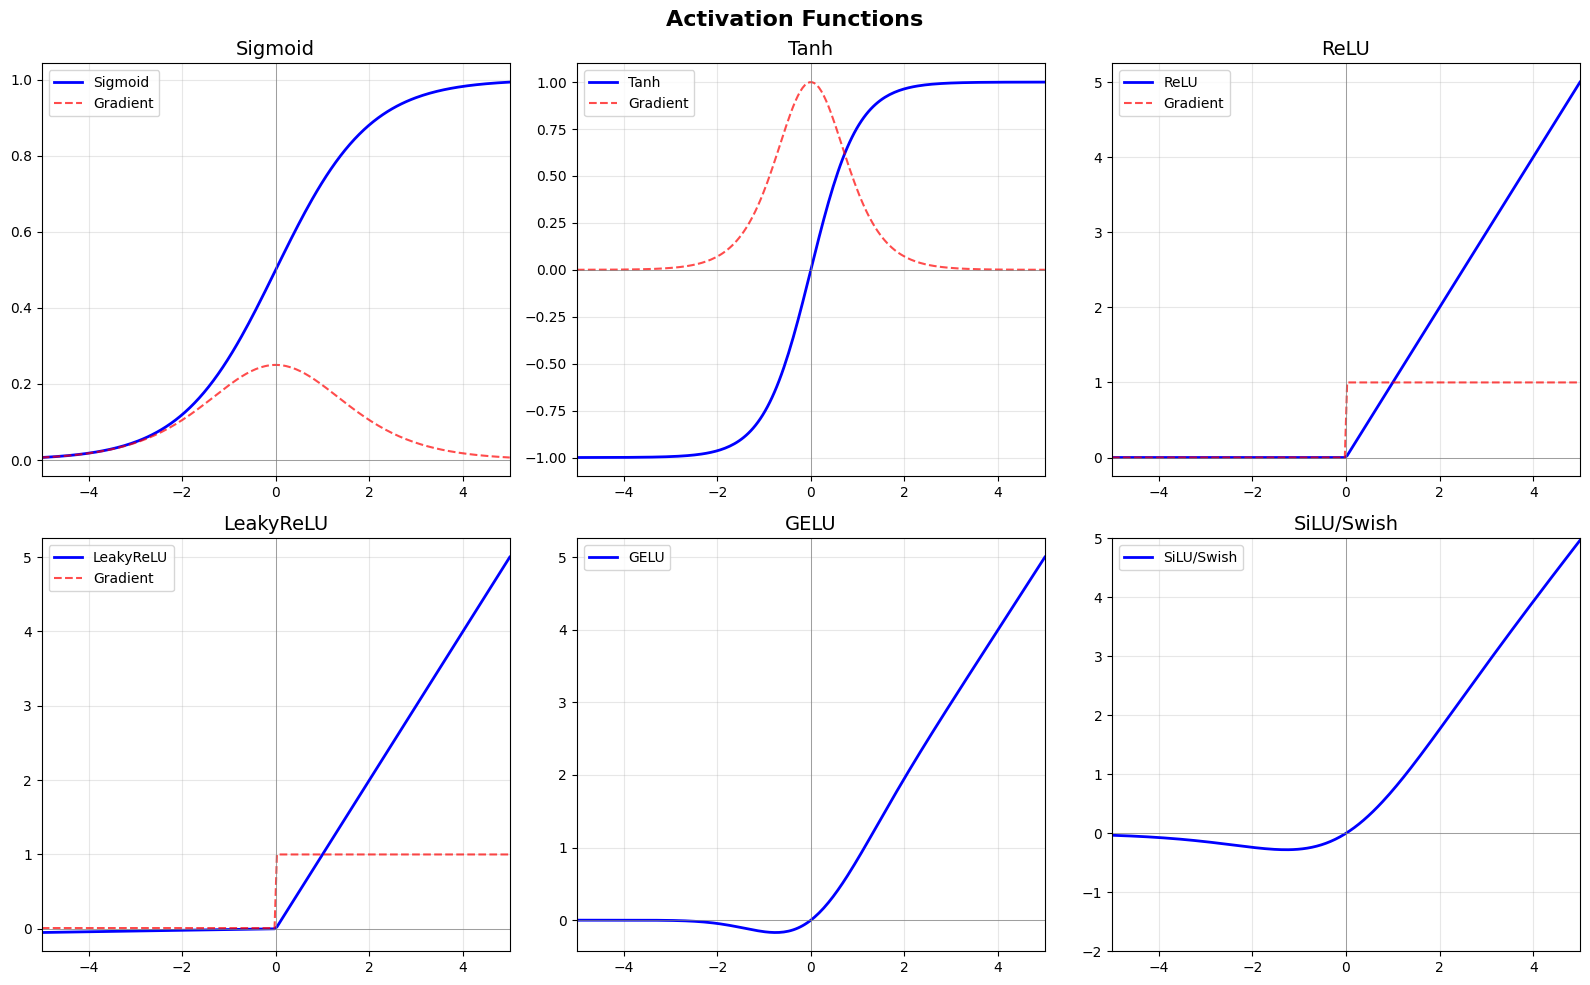


→ 圖表儲存至 plots/05_activations.png


In [2]:
print("=" * 60)
print("1. 激活函數大全")
print("=" * 60)

x = np.linspace(-5, 5, 200)

# 定義每個激活函數（NumPy 版）
activations = {
    'Sigmoid': {
        'fn': lambda x: 1 / (1 + np.exp(-x)),
        'grad': lambda x: (1 / (1 + np.exp(-x))) * (1 - 1 / (1 + np.exp(-x))),
        'desc': 'σ(x) = 1/(1+e⁻ˣ)，輸出 (0,1)',
        'pros': '輸出是機率，適合二元分類最後一層',
        'cons': '梯度消失（x 很大或很小時梯度 ≈ 0）',
    },
    'Tanh': {
        'fn': lambda x: np.tanh(x),
        'grad': lambda x: 1 - np.tanh(x) ** 2,
        'desc': 'tanh(x) = (eˣ-e⁻ˣ)/(eˣ+e⁻ˣ)，輸出 (-1,1)',
        'pros': '零中心（比 Sigmoid 好），適合 RNN',
        'cons': '一樣有梯度消失問題',
    },
    'ReLU': {
        'fn': lambda x: np.maximum(0, x),
        'grad': lambda x: (x > 0).astype(float),
        'desc': 'ReLU(x) = max(0,x)',
        'pros': '計算快、不會梯度消失（正區間）、最常用',
        'cons': 'Dead ReLU 問題（負區間梯度為 0，神經元永遠不更新）',
    },
    'LeakyReLU': {
        'fn': lambda x: np.where(x > 0, x, 0.01 * x),
        'grad': lambda x: np.where(x > 0, 1.0, 0.01),
        'desc': 'LeakyReLU(x) = x if x>0 else 0.01x',
        'pros': '解決 Dead ReLU 問題',
        'cons': '超參數 0.01 需要調',
    },
    'GELU': {
        'fn': lambda x: x * 0.5 * (1 + np.vectorize(lambda v: np.tanh(np.sqrt(2/np.pi) * (v + 0.044715 * v**3)))(x)),
        'grad': None,
        'desc': 'GELU ≈ x·Φ(x)，Φ 是標準常態分佈的 CDF',
        'pros': 'Transformer/BERT/GPT 常用，效果好',
        'cons': '計算稍慢',
    },
    'SiLU/Swish': {
        'fn': lambda x: x * (1 / (1 + np.exp(-x))),
        'grad': None,
        'desc': 'SiLU(x) = x·σ(x)',
        'pros': '平滑版 ReLU，現代模型常用 (LLaMA)',
        'cons': '計算稍慢',
    },
}

# 印出每個函數的特性
for name, info in activations.items():
    print(f"\n{name}: {info['desc']}")
    print(f"  優點: {info['pros']}")
    print(f"  缺點: {info['cons']}")

# 畫圖
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (name, info) in enumerate(activations.items()):
    ax = axes[i]
    y = info['fn'](x)
    ax.plot(x, y, 'b-', linewidth=2, label=name)

    if info['grad'] is not None:
        y_grad = info['grad'](x)
        ax.plot(x, y_grad, 'r--', linewidth=1.5, alpha=0.7, label='Gradient')

    ax.axhline(y=0, color='gray', linewidth=0.5)
    ax.axvline(x=0, color='gray', linewidth=0.5)
    ax.set_title(name, fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-5, 5)

axes[5].set_ylim(-2, 5)
plt.suptitle('Activation Functions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('phase-2-deep-learning/plots/05_activations.png', dpi=100)
plt.show()
print("\n→ 圖表儲存至 plots/05_activations.png")

## 2. PyTorch 用法

In [3]:
print("\n" + "=" * 60)
print("2. PyTorch 中使用激活函數")
print("=" * 60)

x_t = torch.randn(3, 4)

# 兩種用法等價
print("--- 方式 A: 函數式 (torch.nn.functional) ---")
import torch.nn.functional as F
out1 = F.relu(x_t)
out2 = F.sigmoid(x_t)
out3 = F.gelu(x_t)

print("--- 方式 B: 模組式 (nn.Module) ---")
relu = nn.ReLU()
sigmoid = nn.Sigmoid()
gelu = nn.GELU()
out1b = relu(x_t)
out2b = sigmoid(x_t)
out3b = gelu(x_t)

print(f"兩種方式等價: {torch.allclose(out1, out1b)}")

print("""
選擇建議：
  在 nn.Sequential 中 → 用 nn.ReLU()
  在 forward() 中     → 用 F.relu() 或 nn.ReLU() 都可以

  常見寫法：
    # Sequential
    nn.Sequential(nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 10))

    # forward
    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)
""")


2. PyTorch 中使用激活函數
--- 方式 A: 函數式 (torch.nn.functional) ---
--- 方式 B: 模組式 (nn.Module) ---
兩種方式等價: True

選擇建議：
  在 nn.Sequential 中 → 用 nn.ReLU()
  在 forward() 中     → 用 F.relu() 或 nn.ReLU() 都可以

  常見寫法：
    # Sequential
    nn.Sequential(nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 10))

    # forward
    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)



## 3. 選擇指南

In [4]:
print("=" * 60)
print("3. 激活函數選擇指南")
print("=" * 60)

print("""
場景                      推薦激活函數
───────────────────────────────────────────────
隱藏層（一般情況）        ReLU（首選，簡單快速）
隱藏層（更好效果）        GELU / SiLU（現代模型常用）
隱藏層（避免 Dead ReLU）  LeakyReLU / ELU
二元分類輸出層            Sigmoid（輸出機率 0~1）
多類別分類輸出層          不加激活（交給 CrossEntropyLoss 內建 Softmax）
回歸問題輸出層            不加激活（直接輸出數值）
RNN / LSTM 內部           Tanh + Sigmoid

現代趨勢（2024-2026）：
  Transformer: GELU（BERT, GPT）
  LLaMA / Mistral: SiLU (Swish)
  Vision: ReLU 或 GELU
""")

3. 激活函數選擇指南

場景                      推薦激活函數
───────────────────────────────────────────────
隱藏層（一般情況）        ReLU（首選，簡單快速）
隱藏層（更好效果）        GELU / SiLU（現代模型常用）
隱藏層（避免 Dead ReLU）  LeakyReLU / ELU
二元分類輸出層            Sigmoid（輸出機率 0~1）
多類別分類輸出層          不加激活（交給 CrossEntropyLoss 內建 Softmax）
回歸問題輸出層            不加激活（直接輸出數值）
RNN / LSTM 內部           Tanh + Sigmoid

現代趨勢（2024-2026）：
  Transformer: GELU（BERT, GPT）
  LLaMA / Mistral: SiLU (Swish)
  Vision: ReLU 或 GELU



## 4. 實驗：不同激活函數對訓練的影響

4. 實驗：激活函數對訓練的影響


  ReLU        : Test Acc = 96.67%, Final Loss = 0.0713


  Sigmoid     : Test Acc = 83.89%, Final Loss = 1.0134


  Tanh        : Test Acc = 96.11%, Final Loss = 0.1517


  LeakyReLU   : Test Acc = 96.67%, Final Loss = 0.0708


  GELU        : Test Acc = 96.39%, Final Loss = 0.0752


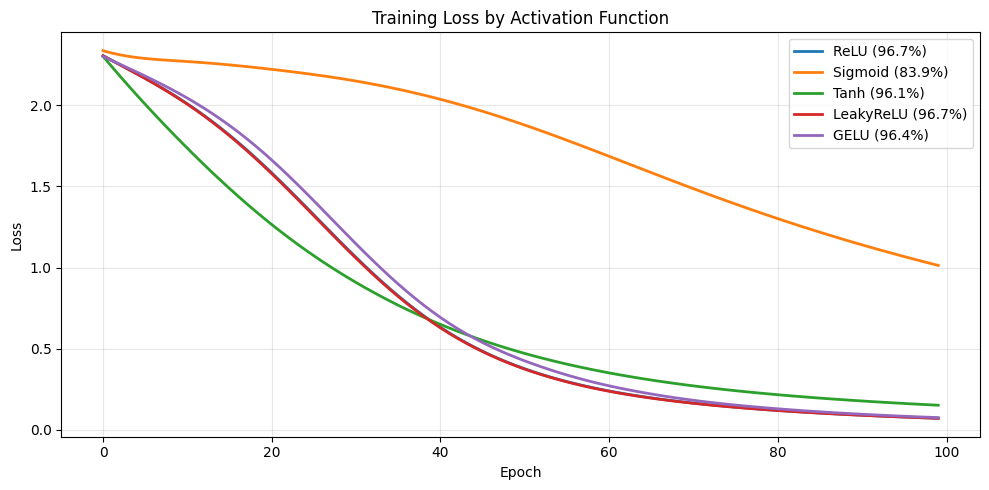

→ 圖表儲存至 plots/05_activation_comparison.png


In [5]:
print("=" * 60)
print("4. 實驗：激活函數對訓練的影響")
print("=" * 60)

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

digits = load_digits()
scaler = StandardScaler()
X = scaler.fit_transform(digits.data).astype(np.float32)
y = digits.target

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
X_tr_t = torch.tensor(X_tr)
y_tr_t = torch.tensor(y_tr, dtype=torch.long)
X_te_t = torch.tensor(X_te)
y_te_t = torch.tensor(y_te, dtype=torch.long)

activation_map = {
    'ReLU': nn.ReLU(),
    'Sigmoid': nn.Sigmoid(),
    'Tanh': nn.Tanh(),
    'LeakyReLU': nn.LeakyReLU(),
    'GELU': nn.GELU(),
}

results = {}

for act_name, act_fn in activation_map.items():
    torch.manual_seed(42)
    model = nn.Sequential(
        nn.Linear(64, 128), act_fn,
        nn.Linear(128, 64), act_fn if act_name != 'Sigmoid' else nn.Sigmoid(),
        nn.Linear(64, 10),
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    losses = []
    for epoch in range(100):
        logits = model(X_tr_t)
        loss = criterion(logits, y_tr_t)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    with torch.no_grad():
        test_acc = (model(X_te_t).argmax(1) == y_te_t).float().mean().item()
    results[act_name] = {'losses': losses, 'test_acc': test_acc}
    print(f"  {act_name:12s}: Test Acc = {test_acc:.2%}, Final Loss = {losses[-1]:.4f}")

# 畫比較圖
plt.figure(figsize=(10, 5))
for name, data in results.items():
    plt.plot(data['losses'], label=f"{name} ({data['test_acc']:.1%})", linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss by Activation Function')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('phase-2-deep-learning/plots/05_activation_comparison.png', dpi=100)
plt.show()
print("→ 圖表儲存至 plots/05_activation_comparison.png")

## 小結

In [6]:
print("\n" + "=" * 60)
print("小結")
print("=" * 60)
print("""
激活函數的核心理解：

  1. 為什麼需要：沒有非線性，深度再多也等於一層
  2. ReLU 是預設首選：簡單、有效、計算快
  3. GELU/SiLU 是現代趨勢：Transformer 模型普遍使用
  4. Sigmoid 只用在輸出層（二元分類）或 Gate（LSTM）
  5. 最後一層分類不加激活：交給 CrossEntropyLoss 處理

下一步：06_loss_and_optimizers.py — 損失函數和優化器
""")


小結

激活函數的核心理解：

  1. 為什麼需要：沒有非線性，深度再多也等於一層
  2. ReLU 是預設首選：簡單、有效、計算快
  3. GELU/SiLU 是現代趨勢：Transformer 模型普遍使用
  4. Sigmoid 只用在輸出層（二元分類）或 Gate（LSTM）
  5. 最後一層分類不加激活：交給 CrossEntropyLoss 處理

下一步：06_loss_and_optimizers.py — 損失函數和優化器

